# Емельянов А.К. ИУ5-63Б
# РК1

Цель:
- выполнить корреляционный анализ признаков
- при наличии пропусков удалить строки/колонки с пропусками
- сделать вывод о возможности построения ML-моделей и вкладе признаков
- построить boxplot для произвольной колонки

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "Admission_Predict_Ver1.1.csv"

df_raw = pd.read_csv(DATA_PATH)

df = df_raw.copy()
df.columns = df.columns.str.strip()
display(df.head())
print("shape:", df.shape)
print("columns:", list(df.columns))

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


shape: (500, 9)
columns: ['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [7]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_cols = na_counts[na_counts > 0]
print("Пропуски по колонкам (только >0):")
display(na_cols)

if len(na_cols) > 0:
    df_clean = df.dropna(axis=1).dropna(axis=0)
else:
    df_clean = df

print("shape (после удаления пропусков):", df_clean.shape)

Пропуски по колонкам (только >0):


Series([], dtype: int64)

shape (после удаления пропусков): (500, 9)


In [8]:
work = df_clean.copy()
if "Serial No." in work.columns:
    work = work.drop(columns=["Serial No."])

num = work.select_dtypes(include=[np.number])

corr = num.corr(method="pearson")
display(corr)

target_col = "Chance of Admit"
if target_col in corr.columns:
    corr_to_target = corr[target_col].drop(index=target_col).sort_values(key=lambda s: s.abs(), ascending=False)
    print("Корреляции с целевой колонкой по убыванию")
    display(corr_to_target)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL Score,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012,0.792228
University Rating,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance of Admit,0.810351,0.792228,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


Корреляции с целевой колонкой по убыванию


CGPA                 0.882413
GRE Score            0.810351
TOEFL Score          0.792228
University Rating    0.690132
SOP                  0.684137
LOR                  0.645365
Research             0.545871
Name: Chance of Admit, dtype: float64

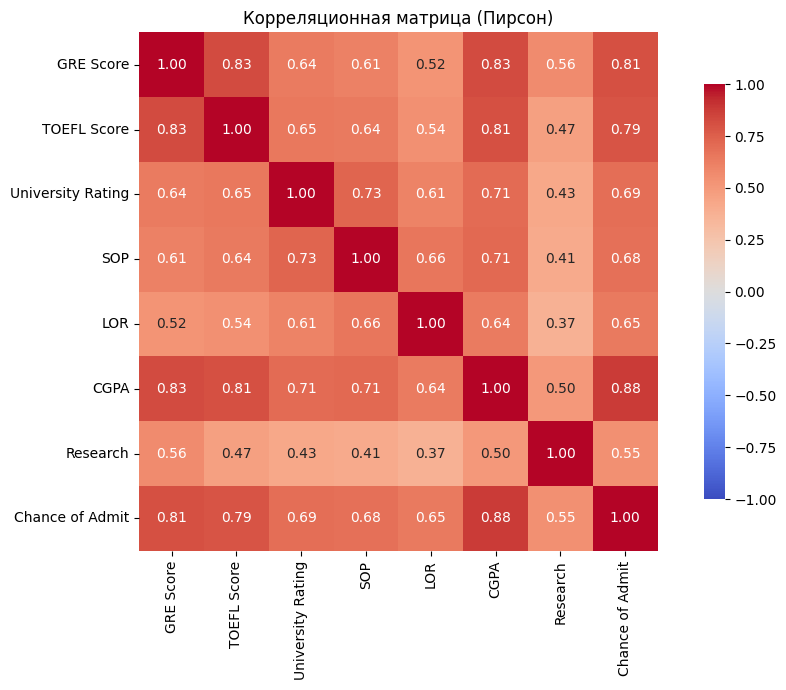

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Корреляционная матрица (Пирсон)")
plt.tight_layout()
plt.show()

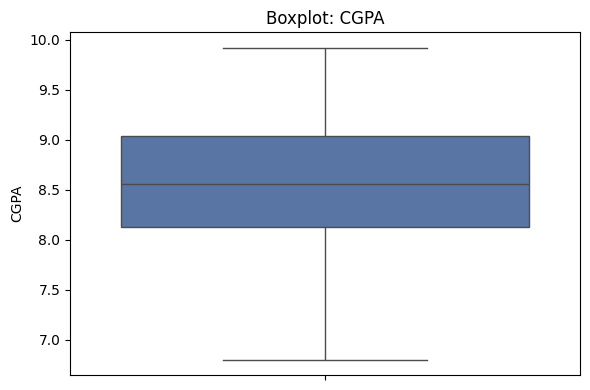

In [10]:

col_for_boxplot = "CGPA"
if col_for_boxplot not in df_clean.columns:
    col_for_boxplot = df_clean.select_dtypes(include=[np.number]).columns[0]

plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean[col_for_boxplot], color="#4C72B0")
plt.title(f"Boxplot: {col_for_boxplot}")
plt.ylabel(col_for_boxplot)
plt.tight_layout()
plt.show()

## Выводы

- **Пропуски**: В данном наборе данных пропуски отсуствуют.
- **Возможность построения ML-моделей**:
  - Целевая переменная Chance of Admit — числовая (регрессия). Подходящие базовые модели: линейная регрессия, случайный лес, градиентный бустинг. Достаточное колличество признаков имеют сильную корелляцию с целевым признаком, данный датасет имеет хороший потенциал для обучения моделей.
  - Признаки в датасете в основном числовые; `Research` — бинарный
  - По корреляционной матрице можно оценить потенциальную мультиколлинеарность (сильные корреляции между признаками).
- **Возможный вклад признаков**:
  - Чем выше модуль корреляции признака с `Chance of Admit`, тем сильнее ожидаемый линейный вклад признака (в рамках линейных зависимостей).
  - Наиболее информативные признаки ожидаются среди тех, у кого |corr| с `Chance of Admit` максимален. 
- CGPA                 0.882413 - сильная связь
- GRE Score            0.810351 - сильная связь
- TOEFL Score          0.792228 - сильная связь
- University Rating    0.690132 - заметная связь
- SOP                  0.684137 - заметная связь
- LOR                  0.645365 -з аметная связь
- Research             0.545871 - заметная связь